<a href="https://colab.research.google.com/github/Abhisek963/machineLearning_Lab/blob/main/26march01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
from sklearn.metrics import classification_report,confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
df=pd.read_csv('naive_bayes_10000_dataset.csv')
df

,gender,cgpa,attendance,internship,projects,communication,aptitude_score,coding_score,backlogs,extracurricular,placed
0,Male,7.19,79.99,Yes,1,Medium,84,63,2,No,0
1,Female,7.54,89.87,Yes,3,High,66,75,0,No,1
2,Male,9.17,82.51,No,3,Medium,62,59,0,Yes,0
3,Male,6.96,63.33,No,1,Medium,49,82,1,No,0
4,Male,9.24,67.42,Yes,4,Low,93,84,1,No,1
...,...,...,...,...,...,...,...,...,...,...,...
9995,Female,8.30,73.10,Yes,2,High,48,97,1,No,1
9996,Male,6.26,89.08,Yes,2,Low,52,84,1,Yes,1
9997,Female,5.72,96.93,Yes,1,High,87,61,1,No,1
9998,Female,8.44,85.49,No,4,Low,92,87,2,Yes,0


In [27]:
target_col=df.columns[-1]
X=df.drop(target_col,axis=1)
y=df[target_col]
le=LabelEncoder()
y=le.fit_transform(y)
X=pd.get_dummies(X)

In [17]:
num_cols=X.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    Q1=X[col].quantile(0.25)
    Q3=X[col].quantile(0.75)
    IQR=Q3-Q1
    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR
    mask=(X[col]>=lower)&(X[col]<=upper)
    X=X[mask]
    y=y[mask]

In [18]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [35]:
nb=GaussianNB()
nb.fit(X_train,y_train)
y_pred_nb=nb.predict(X_test)
nb_acc=accuracy_score(y_test,y_pred_nb)
nb_prec=precision_score(y_test,y_pred_nb,average='weighted')
nb_rec=recall_score(y_test,y_pred_nb,average='weighted')
nb_f1=f1_score(y_test,y_pred_nb,average='weighted')
print("Naive Bayes Accuracy:",nb_acc)
print("Naive Bayes Precision:",nb_prec)
print("Naive Bayes Recall:",nb_rec)
print("Naive Bayes F1 Score:",nb_f1)

print("\nNaive Bayes Confusion Matrix:")
print(confusion_matrix(y_test,y_pred_nb))
print("\nNaive Bayes Classification Report:")
print(classification_report(y_test,y_pred_nb))

Naive Bayes Accuracy: 0.8665
Naive Bayes Precision: 0.8672448502424492
Naive Bayes Recall: 0.8665
Naive Bayes F1 Score: 0.8667356420191213

Naive Bayes Confusion Matrix:
[[1005  146]
 [ 121  728]]

Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.87      0.88      1151
           1       0.83      0.86      0.85       849

    accuracy                           0.87      2000
   macro avg       0.86      0.87      0.86      2000
weighted avg       0.87      0.87      0.87      2000



In [42]:
lr=LogisticRegression(max_iter=1000)
lr.fit(X_train,y_train)
y_pred_lr=lr.predict(X_test)
lr_acc=accuracy_score(y_test,y_pred_lr)
lr_prec=precision_score(y_test,y_pred_lr,average='weighted')
lr_rec=recall_score(y_test,y_pred_lr,average='weighted')
lr_f1=f1_score(y_test,y_pred_lr,average='weighted')
print("Logistic Regression Accuracy:",lr_acc)
print("Logistic Regression Precision:",lr_prec)
print("Logistic Regression Recall:",lr_rec)
print("Logistic Regression F1 Score:",lr_f1)

print("\nLogistic Regression Confusion Matrix:")
print(confusion_matrix(y_test,y_pred_lr))
print("\nLogistic Regression Classification Report:")
print(classification_report(y_test,y_pred_lr))

Logistic Regression Accuracy: 0.907
Logistic Regression Precision: 0.906911465766031
Logistic Regression Recall: 0.907
Logistic Regression F1 Score: 0.9069409206178436

Logistic Regression Confusion Matrix:
[[1062   89]
 [  97  752]]

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92      1151
           1       0.89      0.89      0.89       849

    accuracy                           0.91      2000
   macro avg       0.91      0.90      0.90      2000
weighted avg       0.91      0.91      0.91      2000



In [37]:
if lr_acc>nb_acc:
    print("Logistic Regression better in accuracy")
else:
    print("Naive Bayes better in accuracy")

if lr_prec>nb_prec:
    print("Logistic Regression better in precision")
else:
    print("Naive Bayes better in precision")

if lr_rec>nb_rec:
    print("Logistic Regression better in recall")
else:
    print("Naive Bayes better in recall")

if lr_f1>nb_f1:
    print("Logistic Regression better in f1 score")
else:
    print("Naive Bayes better in f1 score")

Logistic Regression better in accuracy
Logistic Regression better in precision
Logistic Regression better in recall
Logistic Regression better in f1 score


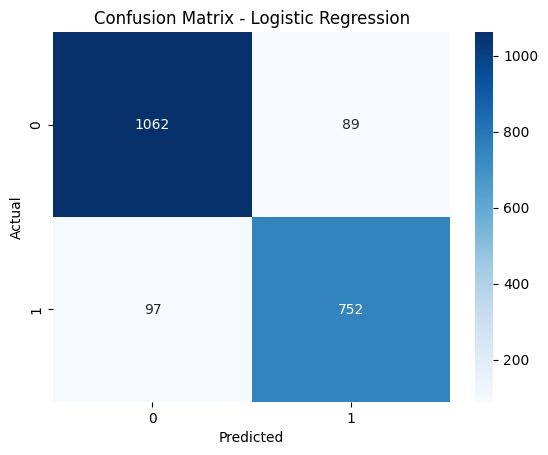

In [44]:
cm=confusion_matrix(y_test,y_pred_lr)
sns.heatmap(cm,annot=True,fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()